progressbar snippet
```python
# progress bar example
from ipywidgets import IntProgress
from IPython.display import display
import time
# Create and display a progress bar
progress = IntProgress(min=0, max=5000)
display(progress)

# Update interval
update_interval = 0.1
update_next = time.time()

# Update the progress bar in a loop
for i in range(5001): # remember that 5001 is not in loop

    # do something here
    time.sleep(0.001)
    value = i
    desc = f"i={i}"

    # avoid flooding
    current_time = time.time()
    if current_time > update_next or i == 5000:
        update_next = current_time + update_interval
        progress.value = value
        progress.description = desc
```

In [1]:
import torch
from ipywidgets import IntProgress
from IPython.display import display
from time import time

learning_rate = 1e-5
epoch = 5000

update_interval = 0.1
update_next = time()

progress = IntProgress(min=0, max=epoch)
display(progress)

dtype = torch.float
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

torch.set_default_dtype(dtype)
torch.set_default_device(device)

x = torch.linspace(-1, 1, 50000)
y = torch.exp(x)

a = torch.randn((), requires_grad=True)
b = torch.randn((), requires_grad=True)
c = torch.randn((), requires_grad=True)
d = torch.randn((), requires_grad=True)
e = torch.randn((), requires_grad=True)

for t in range(1,epoch+1):
    y_pred = a + b * x + c * x**2 + d * x**3 + e * x**4
    loss = (y_pred - y).pow(2).sum()

    loss.backward()

    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad
        e -= learning_rate * e.grad

        a.grad.zero_()
        b.grad.zero_()
        c.grad.zero_()
        d.grad.zero_()
        e.grad.zero_()

    if time() < update_next and t < epoch:
        continue

    update_next = time() + update_interval
    progress.value = t
    progress.description = f"loss={loss.item():.4f}"

print(f"y = {a} + {b} x+ {c} x^2 + {d} x^3 + {e} x^4")

IntProgress(value=0, max=5000)

y = 1.0000313520431519 + 0.9979553818702698 x+ 0.49934932589530945 x^2 + 0.1761384904384613 x^3 + 0.043600570410490036 x^4


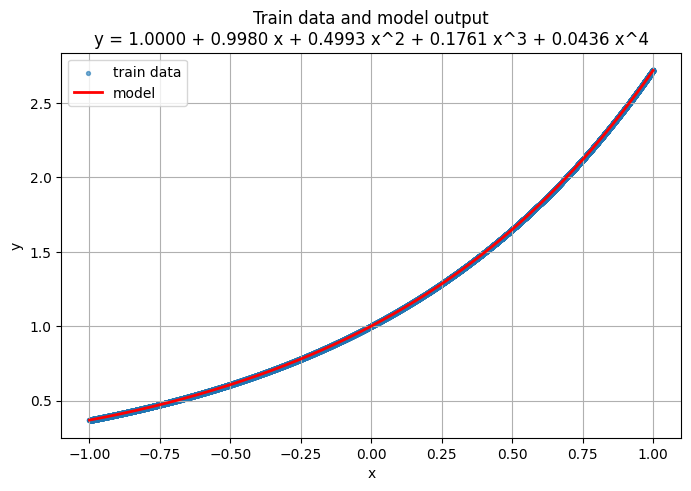

In [2]:
import matplotlib.pyplot as plt

# Compute model output on a dense grid
x_plot = torch.linspace(-1, 1, 500)
with torch.no_grad():
    y_plot = a + b * x_plot + c * x_plot ** 2 + d * x_plot ** 3 + e * x_plot ** 4

# Move tensors to CPU numpy arrays for plotting
x_np = x.cpu().numpy() if x.device.type != 'cpu' else x.numpy()
y_np = y.cpu().numpy() if y.device.type != 'cpu' else y.numpy()
x_plot_np = x_plot.cpu().numpy()
y_plot_np = y_plot.cpu().numpy()

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_np, y_np, s=8, alpha=0.6, label='train data')
plt.plot(x_plot_np, y_plot_np, color='red', linewidth=2, label='model')
plt.xlabel('x')
plt.ylabel('y')
plt.title(
    f"Train data and model output\n"
    f"y = {a.item():.4f} + {b.item():.4f} x + {c.item():.4f} x^2 + {d.item():.4f} x^3 + {e.item():.4f} x^4"
)
plt.legend()
plt.grid(True)
plt.show()
